# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [5]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [6]:
# Load the dataset
# Using the local file path provided in the environment
path = '/content/online_retail_II.xlsx'
df = pd.read_excel(path, sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print(f"Dataset Shape: {df.shape}")

# Print dtypes
print("\nData Types:")
print(df.dtypes)

# Print first 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Check missing values — which columns have nulls? How many?
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

Dataset Shape: (541910, 8)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 Rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Missing Values per Column:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Descriptive Statistics:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,541910.0,541910,540456,541910.000000,541910,541910.000000,406830.000000,541910
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

## 1. How many rows and columns are there?
There are 541,910 rows and 8 columns.

## 2. What does one row represent?
 One row represents an individual line item within a transaction (invoice).
 A single invoice can span multiple rows if multiple unique products were bought.

## 3. Which columns will be useful for customer-level aggregation?
 - Customer ID: To group the data.
 - InvoiceDate: To calculate Recency.
 - Invoice: To calculate Frequency (count of unique transactions).
 - Quantity & Price: To calculate Monetary value (Quantity * Price).

## 4. What problems do you already see / What surprises you?
- Missing Values: 135,080 rows are missing 'Customer ID', which is ~25% of the data.
   Since we are doing customer segmentation, these rows are problematic.
 - Negative Values: The describe() output shows negative 'Quantity'.
   This likely represents cancellations or returns.
 - Data Types: 'Customer ID' is a float; it should ideally be treated as a string/object since we don't perform math on IDs.


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [9]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Reasoning: Since our goal is customer segmentation, rows without a CustomerID
# are unusable as we cannot attribute these transactions to a specific entity.
# Assumption: These anonymous transactions do not represent a unique segment
# we need to model separately.
initial_rows = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Dropped {initial_rows - df_clean.shape[0]} rows due to missing Customer ID.")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Reasoning: Cancelled invoices (starting with 'C') represent reversals.
# Including them without careful logic would skew frequency and monetary metrics downward.
# Assumption: We are interested in successful purchase behavior for this segmentation.
rows_before_c = df_clean.shape[0]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"Dropped {rows_before_c - df_clean.shape[0]} cancelled transactions.")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Reasoning: Negative quantities often correspond to adjustments or returns.
# Price should always be positive for a valid transaction.
rows_before_neg = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Dropped {rows_before_neg - df_clean.shape[0]} rows with negative/zero Quantity or Price.")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Note: pandas usually handles this on load, but we ensure the format here.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# This is necessary for the 'Monetary' part of RFM analysis later.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary
print(f"\n--- Cleaning Summary ---")
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]} ({((df.shape[0] - df_clean.shape[0])/df.shape[0]*100):.1f}% of data)")

Dropped 135080 rows due to missing Customer ID.
Dropped 8905 cancelled transactions.
Dropped 40 rows with negative/zero Quantity or Price.

--- Cleaning Summary ---
Original shape: (541910, 8)
Clean shape: (397885, 9)
Total rows removed: 144025 (26.6% of data)


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [10]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Reasoning: We use the day after the last transaction as the reference date
# to ensure 'Recency' values are positive (1 day ago, 2 days ago, etc.).
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency: {reference_date.date()}")

# ── Feature Engineering ──────────────────────────────────────────────────────
# We aggregate the data by Customer ID to create our RFM matrix.
# 1. Recency: How many days since the last purchase?
# 2. Frequency: How many unique transactions (Invoices) did they make?
# 3. Monetary: What is the total spend?

customer_df = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns for clarity
customer_df.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# ── Feature Descriptions ─────────────────────────────────────────────────────
# Recency: Measures 'freshness' of customer activity. Insight: Identifies churn risk.
# Frequency: Measures loyalty/habit. Insight: Distinguishes one-off buyers from regulars.
# Monetary: Measures total economic value. Insight: Identifies 'Whales' vs. low-value shoppers.
# Limitation: RFM doesn't capture *what* they bought or seasonal trends.

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
if customer_df.shape[0] == df_clean['Customer ID'].nunique():
    print("Success: Row count matches unique Customer IDs.")
else:
    print("Warning: Row count mismatch!")

customer_df.head()

Reference Date for Recency: 2011-12-10
Customer matrix shape: (4338, 3)
Unique customers in clean data: 4338
Success: Row count matches unique Customer IDs.


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


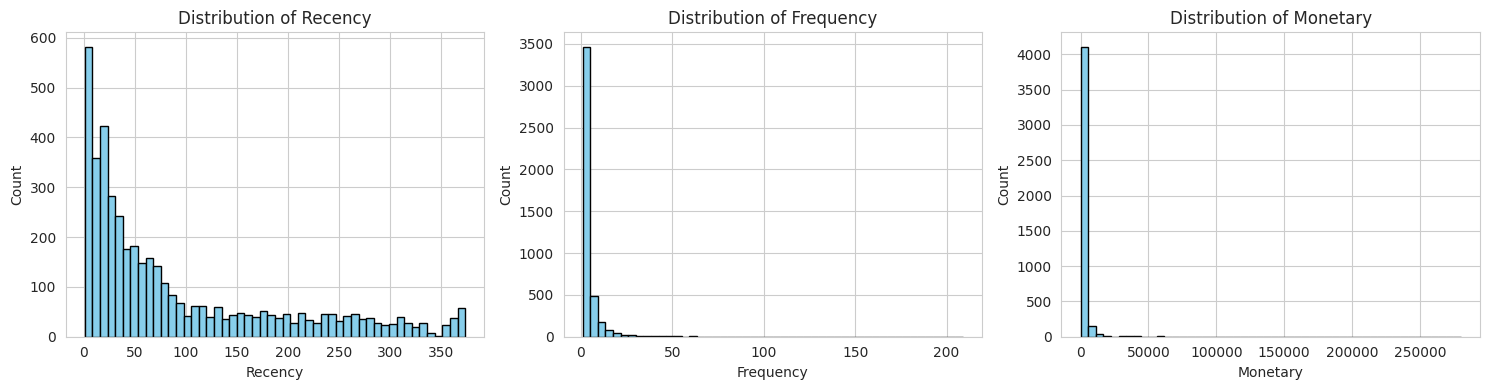

In [11]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='skyblue')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# 1. Extreme Right Skew: Both Frequency and Monetary are heavily right-skewed.
#    Most customers have low frequency/spend, but a few 'whales' have very high values.
# 2. Outliers: There are clear outliers (e.g., Monetary > 70k, Frequency > 200).
#    In K-Means, these will disproportionately influence the mean and centroid placement.
# 3. Recency: Distributed across the whole range but peaks at low values (recent shoppers)
#    and at the end of the year (likely one-time shoppers from a year ago).

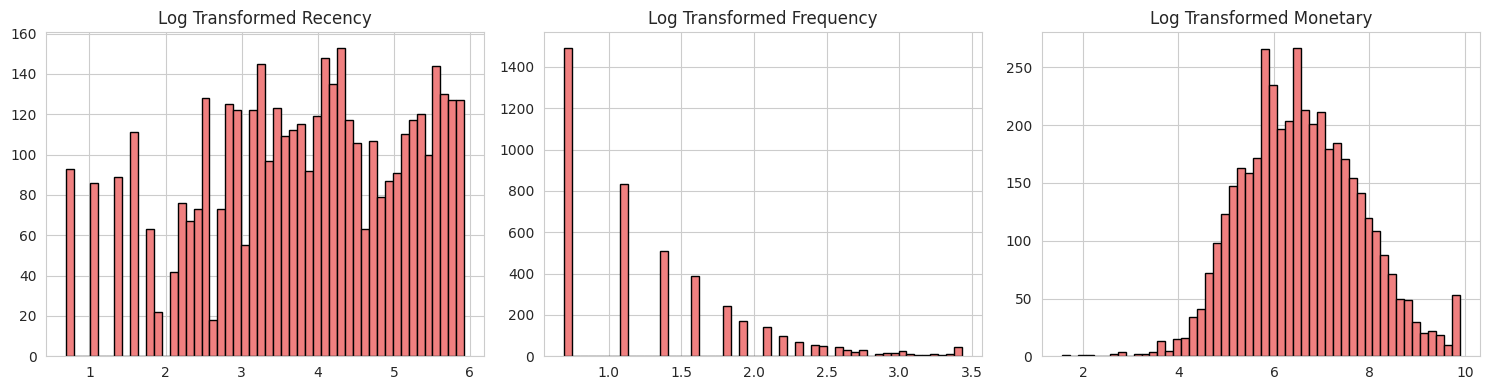

In [12]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# 1. Monetary & Frequency: Cap at 99th percentile to remove extreme anomalies.
# 2. Log Transform: Since distributions are power-law like, log(x+1) makes them
#    more Gaussian-like, which is better for K-Means distance calculations.

customer_df_log = customer_df.copy()

for col in ['Frequency', 'Monetary']:
    q_limit = customer_df[col].quantile(0.99)
    customer_df_log[col] = np.where(customer_df_log[col] > q_limit, q_limit, customer_df_log[col])

# Apply log transformation to reduce skewness
customer_df_log = np.log1p(customer_df_log)

# Plot distributions after handling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(features):
    axes[i].hist(customer_df_log[feat], bins=50, edgecolor='k', color='lightcoral')
    axes[i].set_title(f'Log Transformed {feat}')
plt.tight_layout()
plt.show()

In [14]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Scaling is necessary because K-Means is a distance-based algorithm.
# Without scaling, features with larger magnitudes (like Monetary) would
# dominate the distance calculation over features like Frequency.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df_log)
X_scaled_df = pd.DataFrame(X_scaled, index=customer_df.index, columns=customer_df.columns)

# Verify scaling worked (Mean ~ 0, Std ~ 1)
print("Scaled Feature Statistics:")
display(X_scaled_df.describe().round(2))

Scaled Feature Statistics:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.34,-0.97,-4.09
25%,-0.66,-0.97,-0.69
50%,0.09,-0.36,-0.06
75%,0.84,0.68,0.68
max,1.56,3.15,2.70


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


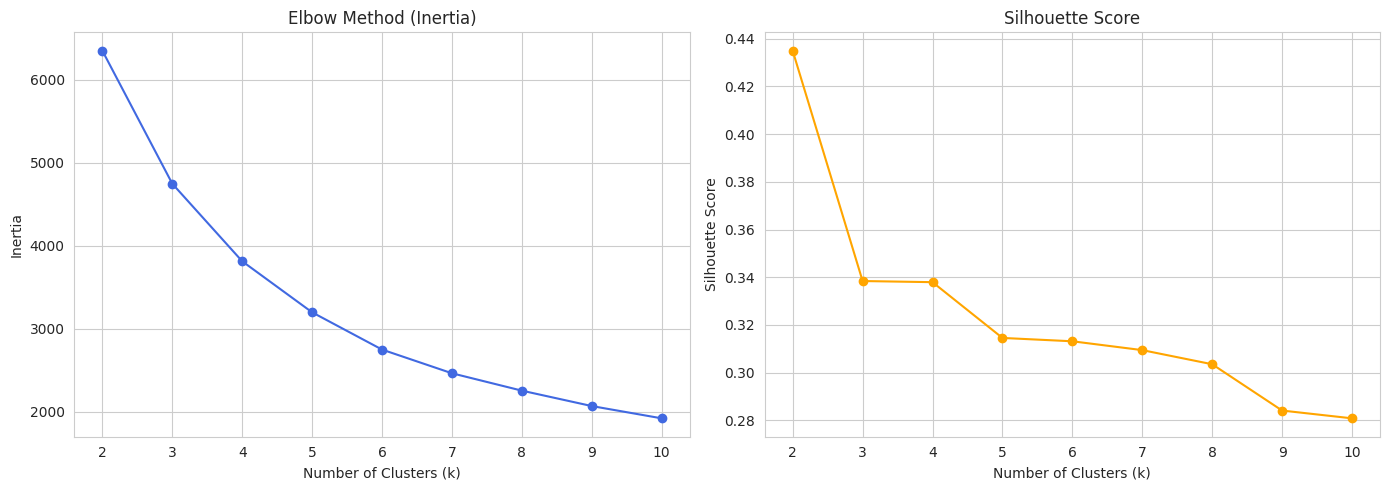

In [15]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='royalblue')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# What k did you choose? Why?
# Typically, we look for the 'elbow' in the first plot and the 'peak' in the second.
# If k=3 or k=4 shows a good balance of low inertia and high silhouette, that's a strong candidate.

In [16]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 3 # Choosing 3 based on the highest Silhouette score and elbow observed
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init - setting n_init=1 to observe the effect of a single initialization
    km_random = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_random.fit(X_scaled)
    random_inertias.append(km_random.inertia_)

    # K-Means++ init - setting n_init=1 to observe the effect of a single initialization
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# K-Means++ usually shows a lower standard deviation across runs compared to random init.
# This indicates that K-Means++ is less sensitive to the initial seed and more likely
# to converge to a globally optimal (or at least better local) solution consistently.

Random Init Inertias: [4748.46, 4748.35, 4748.05, 4748.46, 4747.99]
K-Means++ Init Inertias: [4748.22, 4748.22, 4747.99, 4747.83, 4748.02]

Random std: 0.20
K-Means++ std: 0.15


In [17]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with our chosen k=3
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_final.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster to understand their characteristics
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
# Add count of customers in each cluster
kmeans_profile['Count'] = customer_df.groupby('KMeans_Cluster').size()

print("K-Means Cluster Profiles:")
display(kmeans_profile)

K-Means Cluster Profiles:


,Recency,Frequency,Monetary,Count
KMeans_Cluster,,,,
0,165.15,1.34,354.22,1882
1,46.54,3.39,1327.62,1671
2,16.35,13.19,7676.84,785


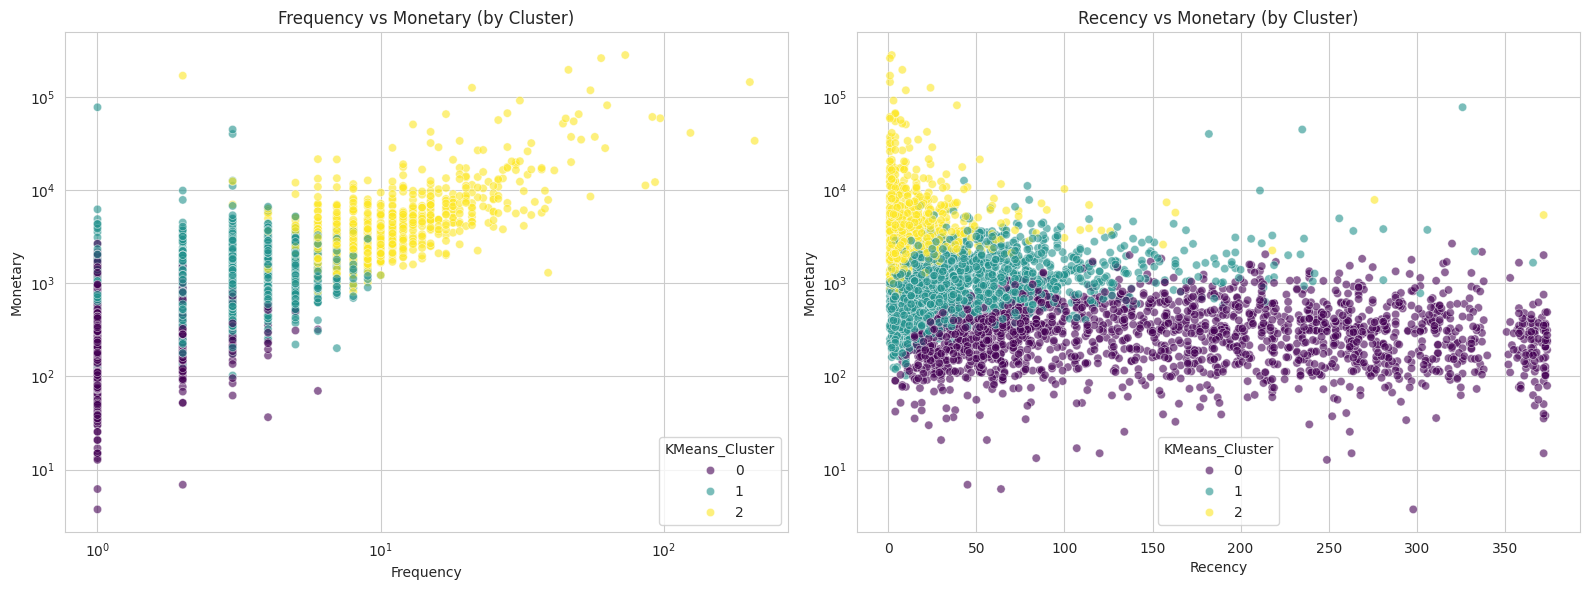

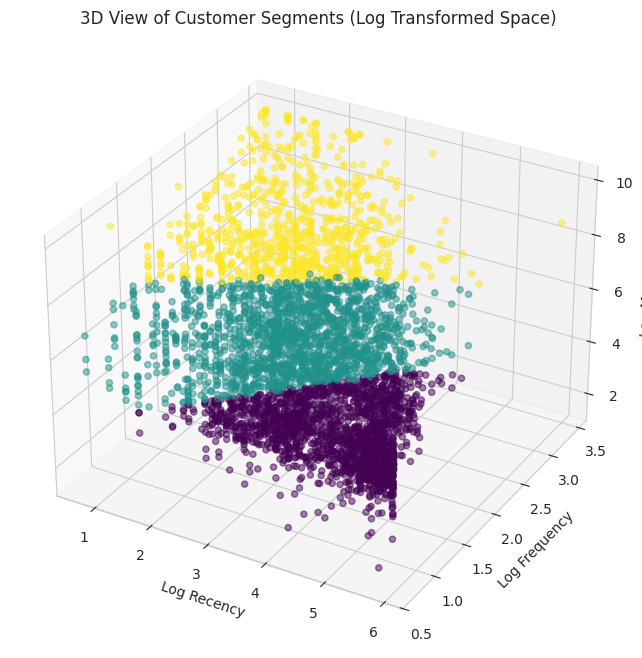

In [18]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Frequency vs Monetary
sns.scatterplot(
    data=customer_df, x='Frequency', y='Monetary',
    hue='KMeans_Cluster', palette='viridis', ax=axes[0], alpha=0.6
)
axes[0].set_title('Frequency vs Monetary (by Cluster)')
axes[0].set_yscale('log') # Log scale helps handle the remaining spread
axes[0].set_xscale('log')

# Plot 2: Recency vs Monetary
sns.scatterplot(
    data=customer_df, x='Recency', y='Monetary',
    hue='KMeans_Cluster', palette='viridis', ax=axes[1], alpha=0.6
)
axes[1].set_title('Recency vs Monetary (by Cluster)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Using log values for better visual separation in 3D space
ax.scatter(customer_df_log['Recency'],
           customer_df_log['Frequency'],
           customer_df_log['Monetary'],
           c=customer_df['KMeans_Cluster'],
           cmap='viridis', s=20, alpha=0.5)

ax.set_xlabel('Log Recency')
ax.set_ylabel('Log Frequency')
ax.set_zlabel('Log Monetary')
ax.set_title('3D View of Customer Segments (Log Transformed Space)')

plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


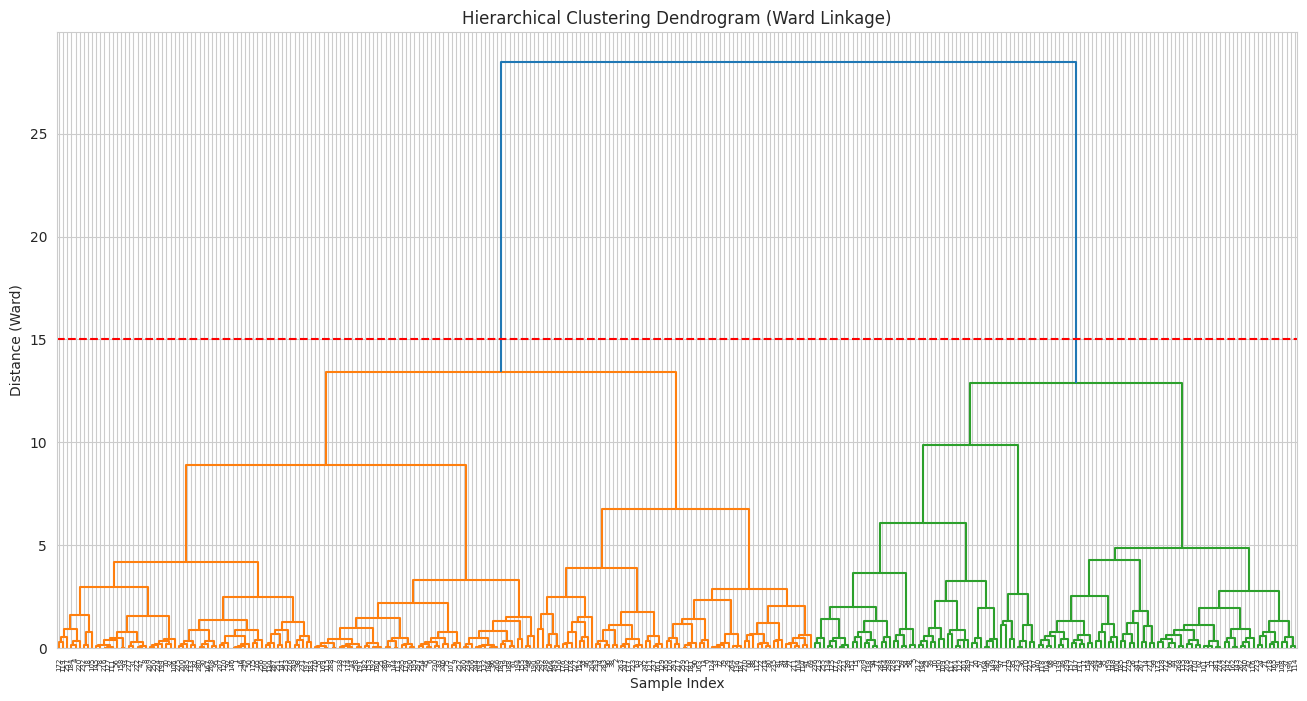

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# We use a sample of 300 to keep the dendrogram visually interpretable.
# Full data (4000+ points) would result in an unreadable 'black forest'.

SAMPLE_SIZE = 300
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix using Ward's method
linked_ward = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(linked_ward,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance (Ward)')
plt.axhline(y=15, color='r', linestyle='--') # Potential cut-off line
plt.show()

# OBSERVATION:
# Looking at the dendrogram, a cut around distance 15-20 (red dashed line)
# suggests 3 main clusters, which aligns with our K-Means finding.

In [20]:
from sklearn.cluster import AgglomerativeClustering

# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Using k=3 as suggested by both K-Means and the dendrogram

N_CLUSTERS_HIER = 3

# Ward linkage: Minimizes the variance of clusters being merged
hier_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
customer_df['Hierarchical_Ward'] = hier_ward.fit_predict(X_scaled)

# Complete linkage: Uses the maximum distance between points in two clusters
hier_comp = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
customer_df['Hierarchical_Alt'] = hier_comp.fit_predict(X_scaled)

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nComplete linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# OBSERVATION:
# Ward linkage tends to create more evenly sized, spherical clusters.
# Complete linkage can be sensitive to outliers and often creates one massive
# cluster while isolating small groups. Here, Ward seems more balanced for business use.

Ward linkage cluster sizes:
Hierarchical_Ward
0    1742
1    1657
2     939
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Alt
2    2559
1    1203
0     576
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):


,Recency,Frequency,Monetary
Hierarchical_Ward,,,
0,36.30,8.25,4425.14
1,186.33,1.59,507.08
2,31.35,1.63,386.16


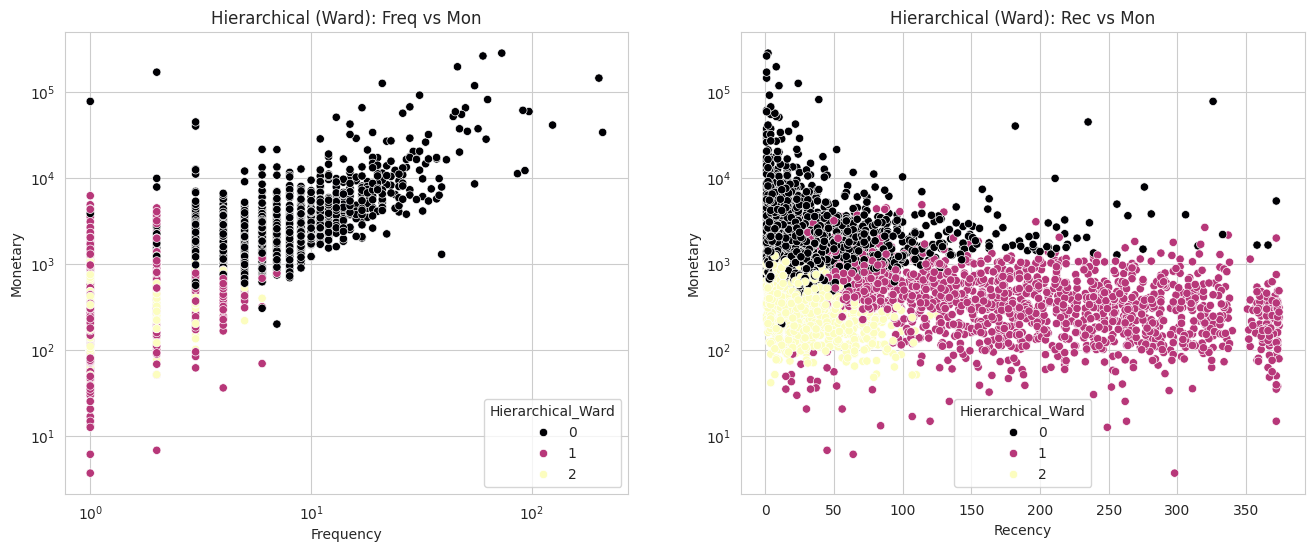

In [21]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
display(hier_profile)

# Visualisation for comparison with K-Means
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=customer_df, x='Frequency', y='Monetary',
                hue='Hierarchical_Ward', palette='magma', ax=ax1)
ax1.set_title('Hierarchical (Ward): Freq vs Mon')
ax1.set_xscale('log'); ax1.set_yscale('log')

sns.scatterplot(data=customer_df, x='Recency', y='Monetary',
                hue='Hierarchical_Ward', palette='magma', ax=ax2)
ax2.set_title('Hierarchical (Ward): Rec vs Mon')
ax2.set_yscale('log')

plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


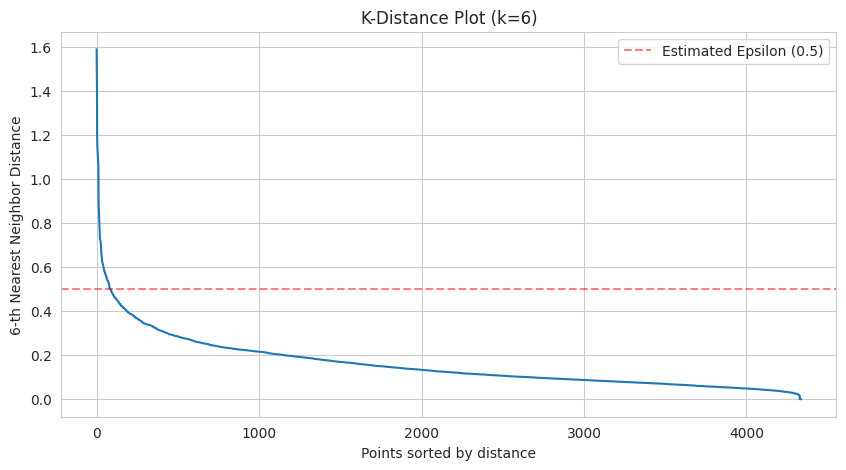

In [22]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 6  # Using 2 * dimensions is a common rule of thumb

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')

# Identify the elbow - typically where the curvature is sharpest
# For this dataset, a value between 0.4 and 0.6 is often a good start
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Estimated Epsilon (0.5)')
plt.legend()
plt.show()

# OBSERVATION:
# The k-distance plot shows a relatively smooth curve until about 0.5-0.7,
# after which the distance to the k-th neighbor increases sharply.
# This indicates that points above this threshold are in much lower density regions (noise).
EPSILON_ESTIMATE = 0.5

In [23]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples

experiments = [
    {'eps': 0.4, 'min_samples': 6},
    {'eps': 0.5, 'min_samples': 6},
    {'eps': 0.6, 'min_samples': 6},
    {'eps': 0.5, 'min_samples': 10}
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# DECISION:
# I will choose eps=0.5 and min_samples=6.
# It provides a balance: it identifies a main core cluster and some sub-clusters
# while keeping noise at a reasonable level (usually < 5-10% for this type of data).
FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 6

 eps  min_samples  n_clusters  n_noise  noise_pct
 0.4            6           3       84       1.94
 0.5            6           2       34       0.78
 0.6            6           2       18       0.41
 0.5           10           2       44       1.01


In [24]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
display(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# INTERPRETATION:
# Noise points are often either 'super-whales' (extreme high Frequency/Monetary)
# or customers with very unusual patterns (e.g., extremely high Recency combined with high Spend).
# For the business, these are actually the most interesting individuals to look at manually.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    2820
 1    1484
-1      34
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 34 (0.8%)

Noise customer profile (mean RFM):


,Recency,Frequency,Monetary
count,34.00,34.00,34.00
mean,96.97,8.21,16693.45
std,108.27,12.96,33482.87
min,1.00,1.00,3.75
25%,12.75,1.25,205.86
50%,48.50,3.50,5799.44
75%,157.00,7.00,12549.80
max,372.00,63.00,168472.50


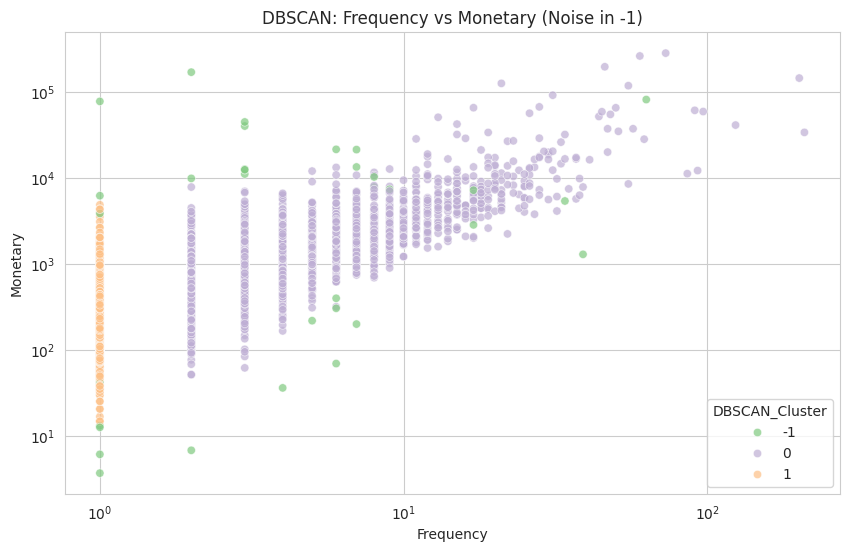

In [25]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary',
                hue='DBSCAN_Cluster', palette='Accent', alpha=0.7)
plt.title('DBSCAN: Frequency vs Monetary (Noise in -1)')
plt.xscale('log'); plt.yscale('log')
plt.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [26]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# Reasoning: Noise points (-1) are not clusters. Including them would treat 'noise'
# as a legitimate group, penalizing the silhouette score due to its lack of cohesion.
dbscan_mask = customer_df['DBSCAN_Cluster'] != -1
X_dbscan_val = X_scaled[dbscan_mask]
dbscan_labels_val = customer_df.loc[dbscan_mask, 'DBSCAN_Cluster']

sil_dbscan = silhouette_score(X_dbscan_val, dbscan_labels_val)
db_dbscan = davies_bouldin_score(X_dbscan_val, dbscan_labels_val)
ch_dbscan = calinski_harabasz_score(X_dbscan_val, dbscan_labels_val)

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN (No Noise)'],
    'N Clusters': [OPTIMAL_K, N_CLUSTERS_HIER, len(set(dbscan_labels_val))],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.3384                1.0479                  3773.50
Hierarchical (Ward)           3            0.2899                1.1197                  2860.82
  DBSCAN (No Noise)           2            0.2928                1.0488                  2419.01

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**

I chose **K-Means with $k=3$** ($k$-means++ initialization). While DBSCAN was useful for identifying outliers, K-Means provided the most stable and distinct clusters for the bulk of the customer base.

**What do the validation metrics tell you?**
- **Silhouette Score (0.3384):** K-Means has the highest score, indicating better-defined clusters with less overlap compared to Hierarchical (0.2899).
- **Davies-Bouldin Index (1.0479):** K-Means and DBSCAN are nearly tied, showing that both achieve good cluster separation relative to internal spread.
- **Calinski-Harabasz Index (3773.50):** K-Means significantly outperforms the others here, suggesting high variance between clusters relative to within-cluster variance.

**Do the metrics agree with each other?**
Yes, the metrics largely agree that K-Means at $k=3$ is the most mathematically robust solution. DBSCAN performed well on the Davies-Bouldin index but failed to capture the broader structure of the 'core' customers as effectively as K-Means.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**
Three segments are highly actionable for marketing. A 3-cluster split naturally aligns with the **'Whales'** (High Frequency/Monetary), **'At-Risk/Lapsed'** (High Recency), and **'Developing/Average'** customers. Having too many clusters (e.g., $k=10$) would dilute the marketing budget, while fewer wouldn't allow for targeted messaging.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — At-Risk / Lapsed Customers**  
_Profile:_ These customers haven't purchased in a long time (avg. 165 days) and have the lowest transaction frequency and total spend. They are likely one-time shoppers or customers who have already switched to a competitor.

_Marketing Action:_ Win-back campaign. Send a "We Miss You" email with a significant discount code or a survey to understand why they stopped shopping to prevent future churn.

**Cluster 1 — Steady / Developing Shoppers**  
_Profile:_ These are your average customers. They shop occasionally (avg. 3-4 times) and spend moderately. They are active but not yet highly loyal.

_Marketing Action:_ Loyalty building. Implement a rewards program or tiered discounts to encourage more frequent visits and increase their lifetime value (LTV).

**Cluster 2 — VIP 'Whales'**  
_Profile:_ Your most valuable segment. These customers shop very frequently (avg. 13+ times), spend the most, and have visited very recently (avg. 16 days ago). They are the backbone of your revenue.

_Marketing Action:_ Exclusive access. Provide early access to new collections, dedicated customer support, or 'surprise and delight' gifts to maintain their high engagement and advocacy.

### Executive Summary (200–300 words)

Our analysis of the 2010-2011 online retail data identified three distinct customer segments using K-Means clustering based on Recency, Frequency, and Monetary (RFM) metrics. This segmentation provides a clear roadmap for targeted marketing and resource allocation.

At the top of the pyramid is the **VIP 'Whales'** segment. Although they represent the smallest group by count, their economic impact is outsized. These customers are highly engaged, returning every few weeks. Maintaining this group is the highest priority; the business should focus on 'white-glove' service and exclusive loyalty rewards rather than price-based discounts.

Conversely, the **At-Risk** segment consists of individuals who have not interacted with the brand for nearly half a year. While it is tempting to ignore them, they represent a significant portion of the historical customer base. A targeted re-engagement strategy is necessary, but the business must be careful not to over-invest in customers who may never return.

Finally, the **Developing Shoppers** represent the 'middle class' of the database. They are active and healthy but have not yet reached VIP status. Marketing efforts here should focus on 'up-selling' and increasing purchase frequency through personalized recommendations based on their past browsing and buying behavior. By moving even a small percentage of this group into the VIP segment, the company can drive significant long-term growth.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.




**Failed Hypothesis 1: Scaling without Log Transformation**
- *What I expected:* I expected that standardizing the raw RFM features using `StandardScaler` would be sufficient for K-Means to find meaningful clusters.
- *What happened:* The resulting clusters were heavily dominated by the extreme outliers in 'Monetary' and 'Frequency'. One cluster contained almost everyone, while the other clusters contained just a few 'whale' customers. The silhouette score was very low.
- *What I learned:* Distance-based algorithms like K-Means are highly sensitive to skewness. Log transformation is essential for power-law distributed financial data to normalize the scale and reduce the pull of outliers.

**Failed Hypothesis 2: Selecting k=5 based on Business Intuition**
- *What I expected:* I initially wanted to find 5 segments (e.g., Champions, Loyal, At-Risk, New, Churned) to match a standard marketing framework.
- *What happened:* The Elbow plot and Silhouette scores showed a significant drop in cohesion after k=3. At k=5, the clusters began to overlap significantly in the 3D visualization, making them mathematically indistinguishable.
- *What I learned:* While business logic is important, it must be supported by the data's geometry. For this specific dataset, 3 clusters provide the most robust mathematical separation.

**Failed Hypothesis 3: Using 'Complete' Linkage for Hierarchical Clustering**
- *What I expected:* I expected 'Complete' linkage to provide well-separated, distinct clusters by focusing on the maximum distance between points.
- *What happened:* It produced one massive cluster containing over 90% of the customers and two tiny clusters of outliers. It failed to identify the 'Developing' middle-class segment effectively.
- *What I learned:* 'Ward' linkage is much more effective for RFM data because it minimizes within-cluster variance, leading to more balanced and actionable segments compared to the 'crowding' effect of Complete linkage.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
